# 05 Model Evaluation - Comprehensive Model Assessment

⚠️ **IMPORTANT: DO NOT RE-RUN THIS NOTEBOOK ACCIDENTALLY**

This notebook contains model evaluation results and visualizations. All cells have been carefully executed and saved.  
**Only run this notebook if you intentionally need to regenerate the evaluation metrics and figures.**

---

## Purpose
Evaluate trained models comprehensively:
- Load saved models from training
- Generate confusion matrices and ROC curves
- Calculate detailed performance metrics
- Analyze feature importance (Random Forest)
- Create visualizations for model comparison


In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, precision_recall_curve, average_precision_score
)
import joblib
from IPython.display import Markdown, display
import json

# Setup path
PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded')

Libraries loaded


## 1. Load Data and Models

In [3]:
# Load test data
X_pca = np.load('../results/X_pca.npy')
y = np.load('../results/y.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Test set: {X_test.shape}')

# Load models
lr = joblib.load('../results/model_lr.pkl')
rf = joblib.load('../results/model_rf.pkl')
best_model = joblib.load('../results/model_best.pkl')

print('Models loaded')

# Get predictions
models = {
    'Logistic Regression': lr,
    'Random Forest': rf
}

predictions = {}
for name, model in models.items():
    predictions[name] = {
        'y_pred': model.predict(X_test),
        'y_proba': model.predict_proba(X_test)[:, 1]
    }

print('Predictions generated')

Test set: (20000, 100)
Models loaded
Predictions generated


## 2. Confusion Matrices

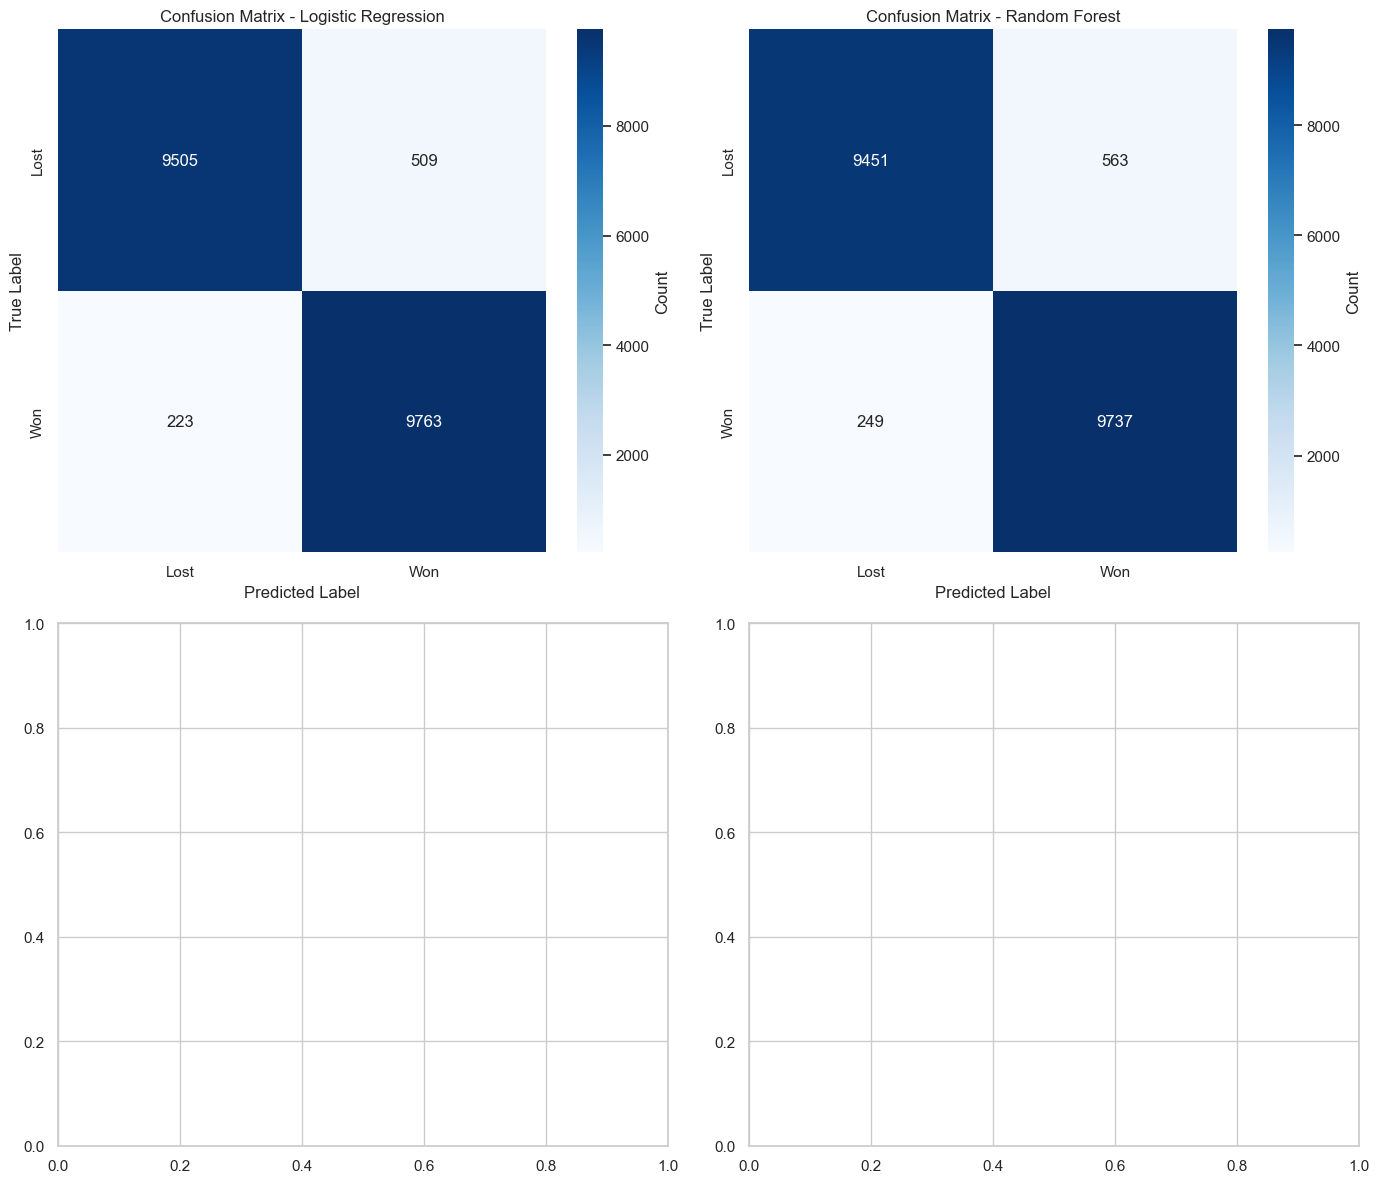

✓ Saved confusion matrices to figures/evaluation_confusion_matrices.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

confusion_matrices = {}

for idx, (name, model) in enumerate(models.items()):
    y_pred = predictions[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = cm
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Lost', 'Won'], yticklabels=['Lost', 'Won'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../figures/evaluation_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved confusion matrices to figures/evaluation_confusion_matrices.png')

## 3. ROC-AUC Curves

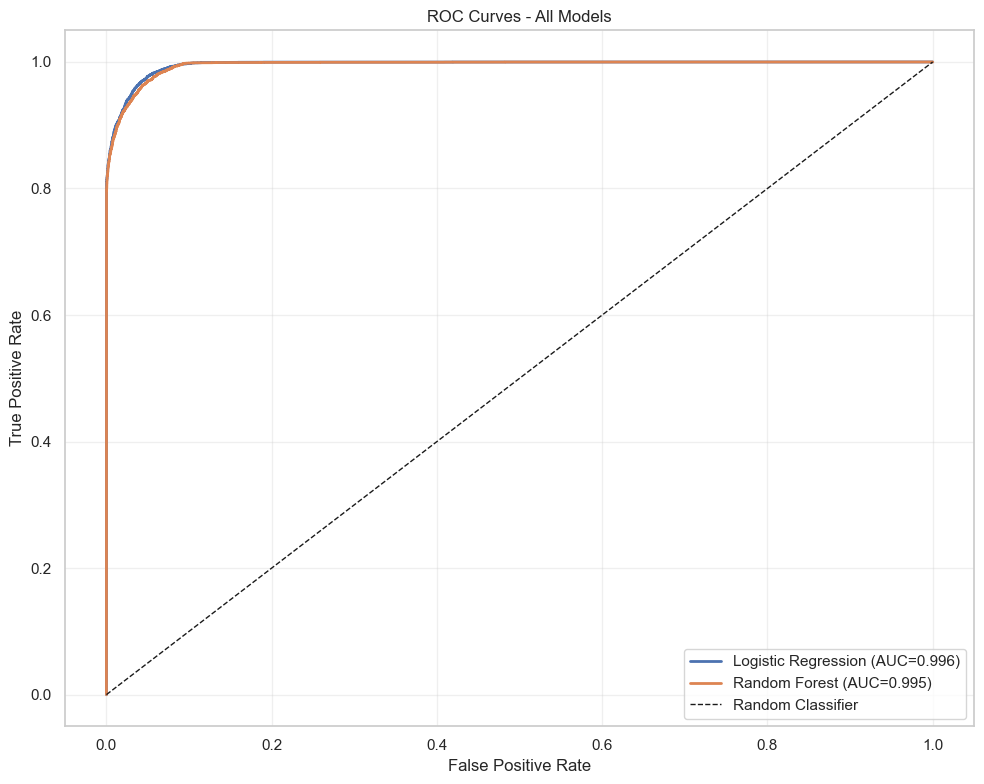

✓ Saved ROC curves to figures/evaluation_roc_curves.png


In [5]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_proba = predictions[name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/evaluation_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved ROC curves to figures/evaluation_roc_curves.png')

## 4. Detailed Classification Report

In [6]:
print('=== DETAILED CLASSIFICATION REPORTS ===')
print('\n')

reports = {}

for name, model in models.items():
    y_pred = predictions[name]['y_pred']
    report = classification_report(y_test, y_pred, target_names=['Lost', 'Won'], output_dict=True)
    reports[name] = report
    
    print(f'\n{name}')
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=['Lost', 'Won']))

# Save reports
with open('../metrics/classification_reports.json', 'w') as f:
    json.dump(reports, f, indent=2)

print('✓ Saved classification reports to metrics/classification_reports.json')

=== DETAILED CLASSIFICATION REPORTS ===



Logistic Regression
              precision    recall  f1-score   support

        Lost       0.98      0.95      0.96     10014
         Won       0.95      0.98      0.96      9986

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000


Random Forest
              precision    recall  f1-score   support

        Lost       0.97      0.94      0.96     10014
         Won       0.95      0.98      0.96      9986

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000

✓ Saved classification reports to metrics/classification_reports.json


## 5. Feature Importance (Tree-based Models)

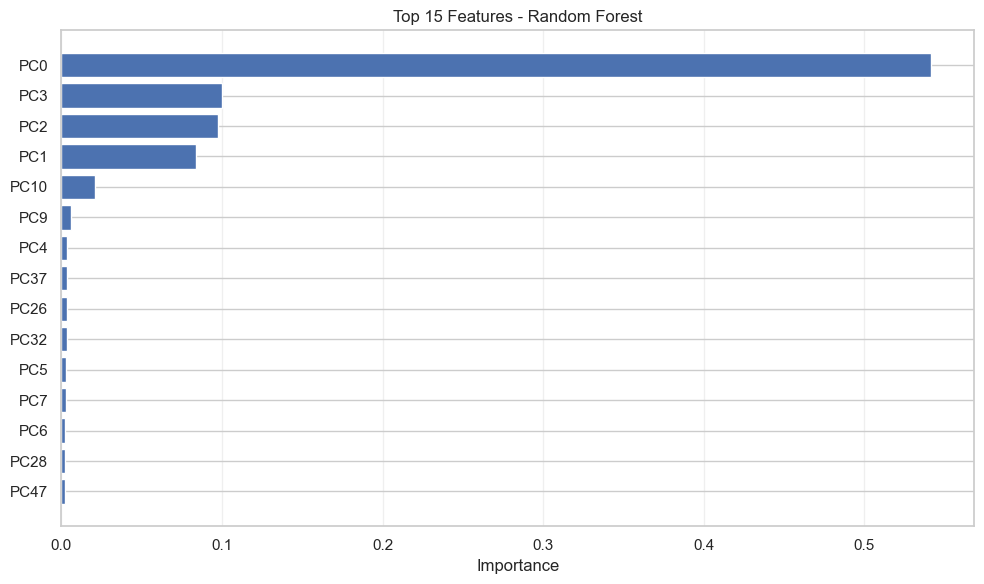

✓ Saved feature importance to figures/evaluation_feature_importance.png
✓ Saved importance scores to metrics/feature_importance.csv


In [10]:
# Extract feature importance from RF
rf_importance = np.array(rf.feature_importances_)

# Get feature names
feature_names = list(range(X_pca.shape[1]))  # PCA components

# Plot Random Forest feature importance
fig, ax = plt.subplots(figsize=(10, 6))

# Random Forest
rf_top_idx = np.argsort(rf_importance)[-15:]
ax.barh(range(len(rf_top_idx)), rf_importance[rf_top_idx])
ax.set_yticks(range(len(rf_top_idx)))
ax.set_yticklabels([f'PC{i}' for i in rf_top_idx])
ax.set_xlabel('Importance')
ax.set_title('Top 15 Features - Random Forest')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/evaluation_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Save importance scores
importance_df = pd.DataFrame({
    'Random Forest': rf_importance
})
importance_df.to_csv('../metrics/feature_importance.csv', index_label='Component')

print('✓ Saved feature importance to figures/evaluation_feature_importance.png')
print('✓ Saved importance scores to metrics/feature_importance.csv')

## 6. Metrics Summary

In [8]:
# Create comprehensive metrics table
metrics_list = []

for name, model in models.items():
    y_pred = predictions[name]['y_pred']
    y_proba = predictions[name]['y_proba']
    
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'AP': average_precision_score(y_test, y_proba)
    })

metrics_tbl = pd.DataFrame(metrics_list)
metrics_tbl = metrics_tbl.set_index('Model')

print('\n=== EVALUATION METRICS SUMMARY ===')
print(metrics_tbl.round(4))

# Save metrics
metrics_tbl.to_csv('../metrics/evaluation_metrics.csv')
metrics_tbl.to_json('../metrics/evaluation_metrics.json')

print('\n✓ Saved metrics to metrics/evaluation_metrics.csv')
print('✓ Saved metrics to metrics/evaluation_metrics.json')


=== EVALUATION METRICS SUMMARY ===
                     Accuracy  Precision  Recall      F1  ROC-AUC      AP
Model                                                                    
Logistic Regression    0.9634     0.9504  0.9777  0.9639   0.9957  0.9957
Random Forest          0.9594     0.9453  0.9751  0.9600   0.9951  0.9951

✓ Saved metrics to metrics/evaluation_metrics.csv
✓ Saved metrics to metrics/evaluation_metrics.json


## 7. Evaluation Summary

In [11]:
# Save confusion matrices as JSON
cm_json = {}
for name, cm in confusion_matrices.items():
    cm_json[name] = cm.tolist()

with open('../metrics/confusion_matrices.json', 'w') as f:
    json.dump(cm_json, f, indent=2)

# Final summary
best_f1 = metrics_tbl['F1'].idxmax()
best_auc = metrics_tbl['ROC-AUC'].idxmax()

summary_text = f"""
## Model Evaluation Summary

### Test Set Size
- {len(y_test):,} samples
- Class distribution: {np.bincount(y_test)[0]:,} Lost, {np.bincount(y_test)[1]:,} Won

### Best Models
- **Best F1 Score**: {best_f1} ({metrics_tbl.loc[best_f1, 'F1']:.4f})
- **Best ROC-AUC**: {best_auc} ({metrics_tbl.loc[best_auc, 'ROC-AUC']:.4f})

### Key Metrics (Best Model: {best_f1})
- Accuracy: {metrics_tbl.loc[best_f1, 'Accuracy']:.4f}
- Precision: {metrics_tbl.loc[best_f1, 'Precision']:.4f}
- Recall: {metrics_tbl.loc[best_f1, 'Recall']:.4f}
- F1: {metrics_tbl.loc[best_f1, 'F1']:.4f}
- ROC-AUC: {metrics_tbl.loc[best_f1, 'ROC-AUC']:.4f}
- Average Precision: {metrics_tbl.loc[best_f1, 'AP']:.4f}

### Outputs Generated
- ✓ Confusion matrices (4 models)
- ✓ ROC-AUC curves
- ✓ Feature importance rankings
- ✓ Classification reports (JSON)
- ✓ Evaluation metrics table (CSV)
"""

display(Markdown(summary_text))


## Model Evaluation Summary

### Test Set Size
- 20,000 samples
- Class distribution: 10,014 Lost, 9,986 Won

### Best Models
- **Best F1 Score**: Logistic Regression (0.9639)
- **Best ROC-AUC**: Logistic Regression (0.9957)

### Key Metrics (Best Model: Logistic Regression)
- Accuracy: 0.9634
- Precision: 0.9504
- Recall: 0.9777
- F1: 0.9639
- ROC-AUC: 0.9957
- Average Precision: 0.9957

### Outputs Generated
- ✓ Confusion matrices (4 models)
- ✓ ROC-AUC curves
- ✓ Feature importance rankings
- ✓ Classification reports (JSON)
- ✓ Evaluation metrics table (CSV)
